# EDA Workflow

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/muhammadtalhaishtiaq/ai-orchestrator/blob/main/02-exploratory-data-analysis/01_eda_workflow.ipynb)


---

## What are we learning?

We’ll walk through a repeatable, step-by-step **Exploratory Data Analysis (EDA) workflow** that you can apply to any tabular dataset. By the end you’ll know how to systematically inspect, clean, and visualise data before building models.

## The idea in plain English

Think of EDA like a doctor’s check-up: first you record basic stats (temperature, heart-rate), then you look for anything unusual (rashes, pain), and finally you order targeted tests. Similarly, we start with shape & dtypes, hunt for missing values and outliers, then visualise relationships to decide next steps.

## Setup

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid')
print('Setup done!')

Setup done!


## Step 1 — Load data

In [2]:
# Built-in Seaborn dataset: Titanic passengers
df = sns.load_dataset('titanic')
print(df.shape)
df.head()

(891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## Step 2 — Apply EDA Workflow

In [3]:
# 1. Basic structure
print('Shape:', df.shape)
print('\nColumn types:\n', df.dtypes)

# 2. Missing values
missing = df.isna().sum().sort_values(ascending=False)
print('\nMissing counts:\n', missing[missing > 0])

# 3. Duplicate rows
dups = df.duplicated().sum()
print(f'\nDuplicate rows: {dups}')

# 4. Numeric summary
print('\nNumeric describe:\n', df.describe())

Shape: (891, 15)

Column types:
 survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object

Missing counts:
 deck           688
age            177
embarked         2
embark_town      2
dtype: int64

Duplicate rows: 107

Numeric describe:
          survived      pclass         age       sibsp       parch        fare
count  891.000000  891.000000  714.000000  891.000000  891.000000  891.000000
mean     0.383838    2.308642   29.699118    0.523008    0.381594   32.204208
std      0.486592    0.836071   14.526497    1.102743    0.806057   49.693429
min      0.000000    1.000000    0.420000    0.000000    0.000000    0.000000
25%      0.000000    2.000000   20.125000    0.000000  

In [4]:
# 5. Categorical summary
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    print(f'\n{col} value counts:')
    print(df[col].value_counts().head(8))


sex value counts:
sex
male      577
female    314
Name: count, dtype: int64

embarked value counts:
embarked
S    644
C    168
Q     77
Name: count, dtype: int64

who value counts:
who
man      537
woman    271
child     83
Name: count, dtype: int64

embark_town value counts:
embark_town
Southampton    644
Cherbourg      168
Queenstown      77
Name: count, dtype: int64

alive value counts:
alive
no     549
yes    342
Name: count, dtype: int64


In [5]:
# 6. Quick outlier check for fare (right-skewed metric)
q1, q3 = df['fare'].quantile([0.25, 0.75])
iqr = q3 - q1
lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
outliers = df[(df['fare'] < lower) | (df['fare'] > upper)]
print(f'Fare outliers: {len(outliers)} rows ({len(outliers)/len(df)*100:.1f}%)')

Fare outliers: 116 rows (13.0%)


## Step 3 — Visualise

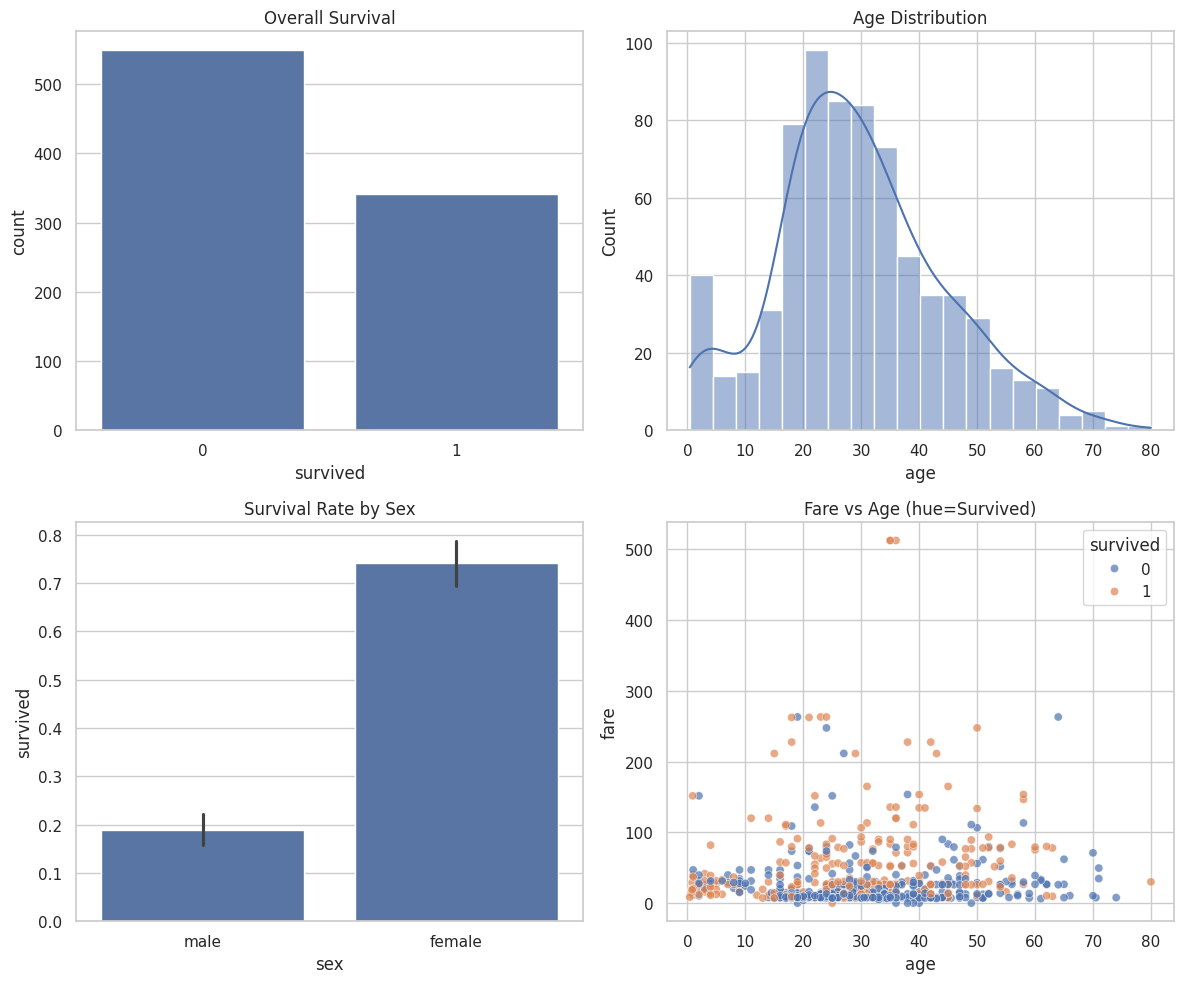

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Survival counts
sns.countplot(x='survived', data=df, ax=axes[0,0])
axes[0,0].set_title('Overall Survival')

# Age distribution
sns.histplot(df['age'].dropna(), kde=True, ax=axes[0,1])
axes[0,1].set_title('Age Distribution')

# Survival by sex
sns.barplot(x='sex', y='survived', data=df, ax=axes[1,0])
axes[1,0].set_title('Survival Rate by Sex')

# Fare vs Age coloured by survival
sns.scatterplot(x='age', y='fare', hue='survived', data=df, alpha=0.7, ax=axes[1,1])
axes[1,1].set_title('Fare vs Age (hue=Survived)')

plt.tight_layout()
plt.show()

## Results & interpretation

In [7]:
# Key take-aways printed clearly
print('Key insights:')
print(f'1. Survival rate: {df["survived"].mean():.1%}')
print(f'2. Females survive at {df.groupby("sex")["survived"].mean()["female"]:.1%} vs males {df.groupby("sex")["survived"].mean()["male"]:.1%}')
print(f'3. Age has {df["age"].isna().sum()} missing values ({df["age"].isna().mean():.1%})')
print(f'4. Fare outliers suggest premium tickets; max fare = ${df["fare"].max():.0f}')

Key insights:
1. Survival rate: 38.4%
2. Females survive at 74.2% vs males 18.9%
3. Age has 177 missing values (19.9%)
4. Fare outliers suggest premium tickets; max fare = $512


## Summary

- Follow a fixed order: structure → missing → duplicates → numeric → categorical → outliers → visualise
- Always check dtypes; misclassified columns cause silent bugs
- Missing data and outliers guide imputation & modelling choices
- Quick plots (count, hist, bar, scatter) reveal relationships faster than tables
- Document insights inline so your future self (and teammates) know why decisions were made

## Exercises

1. Replace the Titanic dataset with the built-in `mpg` dataset and run the same workflow—list two new insights.
2. Write a reusable Python function `eda_report(df)` that returns a dictionary with keys: `shape`, `missing`, `numeric_summary`, `categorical_summary`.
3. Extend the outlier check to multiple numeric columns and return a dataframe showing only rows that contain outliers in any column.

In [8]:
# Your code here